### Step 0 :- Import Libraries

In [1]:
# Import NumPy
import numpy as np

# Import Pandas
import pandas as pd

# Import Matplotlib
import matplotlib.pyplot as plt

# Import Path for file handling
from pathlib import Path

# Import KaggleHub
import kagglehub

### Step 1 :- Authenticate with Kaggle

> Before downloading any Kaggle dataset or competition files, authentication is required.

> In this notebook, we will use the **getpass()** method.

#### Why use getpass()?

> - Hides the API Token while typing.
> - Prevents accidental exposure of sensitive credentials.
> - Safer than hardcoding the API Token.
> - Recommended for learning and demonstration notebooks.

> **Note**

> - Enter your Kaggle API Token when prompted.

> - Your input will remain hidden while typing.

In [2]:
# Import required modules
import os
from getpass import getpass

# Prompt the user to securely enter the Kaggle API Token
api_token = getpass('Enter your Kaggle API Token: ')

# Store the API Token as an environment variable
os.environ['KAGGLE_API_TOKEN'] = api_token

# Display a confirmation message
print('Authentication completed successfully.')

Enter your Kaggle API Token:  ········


Authentication completed successfully.


### Step 2 :- Download the Competition Files

> Download the latest competition files using KaggleHub.

> Competition Name

> - Store Sales - Time Series Forecasting

In [3]:
# Download the latest competition files
competition_path = kagglehub.competition_download('store-sales-time-series-forecasting')

# Display the download location
print(competition_path)

C:\Users\neyaz\.cache\kagglehub\competitions\store-sales-time-series-forecasting


### Step 3 :- Create the Dataset Path

> Convert the downloaded path into a Path object.

In [4]:
# Convert the download path into a Path object
dataset_path = Path(competition_path)

### Step 4 :- Display Available Files

> Display all files available in the competition folder.

In [5]:
# Display all available files
list(dataset_path.iterdir())

[WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/holidays_events.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/oil.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/sample_submission.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/stores.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/test.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/train.csv'),
 WindowsPath('C:/Users/neyaz/.cache/kagglehub/competitions/store-sales-time-series-forecasting/transactions.csv')]

### Step 5 :- Load the Competition Datasets

In [6]:
# Load the sales dataset
sales_data = pd.read_csv(dataset_path / "train.csv")

# Load the stores dataset
stores_data = pd.read_csv(dataset_path / "stores.csv")

# Load the transactions dataset
transactions_data = pd.read_csv(dataset_path / "transactions.csv")

# Load the holidays dataset
holidays_data = pd.read_csv(dataset_path / "holidays_events.csv")

#### Sales Dataset

In [7]:
# Display sales dataset information
print(f'Sales Dataset Shape: {sales_data.shape}')

print(f'\nSales Dataset Columns:\n{sales_data.columns}')

sales_data.head()

Sales Dataset Shape: (3000888, 6)

Sales Dataset Columns:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


#### Stores Dataset

In [8]:
# Display stores dataset information
print(f'Stores Dataset Shape: {stores_data.shape}')

print(f'\nStores Dataset Columns:\n{stores_data.columns}')

stores_data.head()

Stores Dataset Shape: (54, 5)

Stores Dataset Columns:
Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='str')


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


#### Transactions Dataset

In [9]:
# Display transactions dataset information
print(f'Transactions Dataset Shape: {transactions_data.shape}')

print(f'\nTransactions Dataset Columns:\n{transactions_data.columns}')

transactions_data.head()

Transactions Dataset Shape: (83488, 3)

Transactions Dataset Columns:
Index(['date', 'store_nbr', 'transactions'], dtype='str')


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


#### Holidays Dataset

In [10]:
# Display holidays dataset information
print(f'Holidays Dataset Shape: {holidays_data.shape}')

print(f'\nHolidays Dataset Columns:\n{holidays_data.columns}')

holidays_data.head()

Holidays Dataset Shape: (350, 6)

Holidays Dataset Columns:
Index(['date', 'type', 'locale', 'locale_name', 'description', 'transferred'], dtype='str')


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


### Step 6 :- Data Cleaning

#### Sales Dataset
#### Remove Duplicate Records

In [11]:
# Check dataset size
print(f'Before removing duplicates: {sales_data.shape}')

# Remove duplicate records
sales_data = sales_data.drop_duplicates()

# Check dataset size again
print(f'After removing duplicates: {sales_data.shape}')

# Verify duplicate records
print(f'Remaining Duplicates: {sales_data.duplicated().sum()}')

Before removing duplicates: (3000888, 6)
After removing duplicates: (3000888, 6)
Remaining Duplicates: 0


#### Handle Missing Values

In [12]:
# Check missing values
print(f'Missing Values:\n{sales_data.isnull().sum()}')

# Fill missing numeric values
numeric_columns = [
    'sales',
    'onpromotion']

sales_data[numeric_columns] = (
    sales_data[numeric_columns]
    .fillna(0))

# Verify missing values
print(f'\nMissing Values After Cleaning:\n{sales_data.isnull().sum()}')

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Missing Values After Cleaning:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


#### Format Date Column

In [13]:
# Convert date column
sales_data['date'] = pd.to_datetime(
    sales_data['date'])

print(sales_data['date'].dtype)

datetime64[us]


#### Stores Dataset
#### Check Missing Values

In [14]:
# Check missing values
print(f'Missing Values:\n{stores_data.isnull().sum()}')

# Fill missing values
stores_data = stores_data.fillna('Unknown')

print(f'\nMissing Values After Cleaning:\n{stores_data.isnull().sum()}')

Missing Values:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Missing Values After Cleaning:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


#### Transactions Dataset
#### Remove Duplicate Records

In [15]:
# Remove duplicate records
transactions_data = transactions_data.drop_duplicates()

print(
    f'Remaining Duplicates: '
    f'{transactions_data.duplicated().sum()}')

Remaining Duplicates: 0


#### Handle Missing Values

In [16]:
# Check missing values
print(f'Missing Values:\n{transactions_data.isnull().sum()}')

transactions_data['transactions'] = (
    transactions_data['transactions']
    .fillna(0))

print(f'\nMissing Values After Cleaning:\n{transactions_data.isnull().sum()}')

Missing Values:
date            0
store_nbr       0
transactions    0
dtype: int64

Missing Values After Cleaning:
date            0
store_nbr       0
transactions    0
dtype: int64


#### Format Date Column

In [17]:
# Convert date column
transactions_data['date'] = pd.to_datetime(
    transactions_data['date'])

print(transactions_data['date'].dtype)

datetime64[us]


#### Holidays Dataset
#### Remove Duplicate Records

In [18]:
# Remove duplicate records
holidays_data = holidays_data.drop_duplicates()

print(
    f'Remaining Duplicates: '
    f'{holidays_data.duplicated().sum()}')

Remaining Duplicates: 0


#### Handle Missing Values

In [19]:
# Check missing values
print(f'Missing Values:\n{holidays_data.isnull().sum()}')

holidays_data = holidays_data.fillna('Unknown')

print(f'\nMissing Values After Cleaning:\n{holidays_data.isnull().sum()}')

Missing Values:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

Missing Values After Cleaning:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64


#### Format Date Column

In [20]:
# Convert date column
holidays_data['date'] = pd.to_datetime(
    holidays_data['date'])

print(holidays_data['date'].dtype)

datetime64[us]


#### Summary

In [21]:
# Display cleaned dataset shapes
print(f'Sales Dataset: {sales_data.shape}')

print(f'Stores Dataset: {stores_data.shape}')

print(f'Transactions Dataset: {transactions_data.shape}')

print(f'Holidays Dataset: {holidays_data.shape}')

Sales Dataset: (3000888, 6)
Stores Dataset: (54, 5)
Transactions Dataset: (83488, 3)
Holidays Dataset: (350, 6)


### Step 7 :- Merge Dataset

#### Merge Sales & Stores Dataset

In [22]:
# Merge sales and stores dataset
merged_data = pd.merge(

    sales_data,

    stores_data,

    on = 'store_nbr',

    how = 'left')

# Display merged dataset shape
print(f'Shape: {merged_data.shape}')

merged_data.head()

Shape: (3000888, 10)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


#### Merge Transactions Dataset

In [23]:
# Merge transactions dataset
merged_data = pd.merge(

    merged_data,

    transactions_data,

    on = ['date', 'store_nbr'],

    how = 'left')

# Fill missing transaction values
merged_data['transactions'] = (
    merged_data['transactions']
    .fillna(0))

# Display merged dataset shape
print(f'Shape: {merged_data.shape}')

merged_data.head()

Shape: (3000888, 11)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0


#### Merge Holidays Dataset

In [24]:
# Merge holidays dataset
merged_data = pd.merge(
    merged_data,
    holidays_data,
    on='date',
    how='left')

# Rename columns
merged_data.rename(
    columns={
        'type_x': 'store_type',
        'type_y': 'holiday_type'
    },
    inplace=True)

# Fill missing holiday values
holiday_columns = [
    'holiday_type',
    'locale',
    'locale_name',
    'description',
    'transferred']

merged_data[holiday_columns] = merged_data[holiday_columns].fillna({
    'holiday_type': 'No Holiday',
    'locale': 'No Holiday',
    'locale_name': 'No Holiday',
    'description': 'No Holiday',
    'transferred': False})

merged_data.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,transactions,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False


#### Verify Final Dataset

In [25]:
# Display final dataset information
print(f'Shape: {merged_data.shape}')

print(f'\nColumns:\n{merged_data.columns}')

merged_data.head()

Shape: (3054348, 16)

Columns:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'transactions', 'holiday_type',
       'locale', 'locale_name', 'description', 'transferred'],
      dtype='str')


,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,transactions,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False


#### Check Missing Values

In [26]:
# Check missing values
print(

    merged_data.isnull().sum())

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
store_type      0
cluster         0
transactions    0
holiday_type    0
locale          0
locale_name     0
description     0
transferred     0
dtype: int64


#### Final Dataset Summary

In [27]:
# Display dataset information
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 16 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[us]
 2   store_nbr     int64         
 3   family        str           
 4   sales         float64       
 5   onpromotion   int64         
 6   city          str           
 7   state         str           
 8   store_type    str           
 9   cluster       int64         
 10  transactions  float64       
 11  holiday_type  str           
 12  locale        str           
 13  locale_name   str           
 14  description   str           
 15  transferred   object        
dtypes: datetime64[us](1), float64(2), int64(4), object(1), str(8)
memory usage: 572.4+ MB


### Step 8 :- Feature Engineering

#### Create Year

In [28]:
# Create year column
merged_data['Year'] = (
    merged_data['date']
    .dt.year)

merged_data[['date', 'Year']].head()

,date,Year
0,2013-01-01,2013
1,2013-01-01,2013
2,2013-01-01,2013
3,2013-01-01,2013
4,2013-01-01,2013


#### Create Month

In [29]:
# Create month column
merged_data['Month'] = (
    merged_data['date']
    .dt.month)

merged_data[['date', 'Month']].head()

,date,Month
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1


#### Create Month Name

In [30]:
# Create month name column
merged_data['Month_Name'] = (
    merged_data['date']
    .dt.month_name())

merged_data[['date', 'Month_Name']].head()

,date,Month_Name
0,2013-01-01,January
1,2013-01-01,January
2,2013-01-01,January
3,2013-01-01,January
4,2013-01-01,January


#### Create Week Number

In [31]:
# Create week number column
merged_data['Week'] = (
    merged_data['date']
    .dt.isocalendar()
    .week)

merged_data[['date', 'Week']].head()

,date,Week
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1


#### Create Day

In [32]:
# Create day column
merged_data['Day'] = (
    merged_data['date']
    .dt.day)

merged_data[['date', 'Day']].head()

,date,Day
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1


#### Create Day Name

In [33]:
# Create day name column
merged_data['Day_Name'] = (
    merged_data['date']
    .dt.day_name())

merged_data[['date', 'Day_Name']].head()

,date,Day_Name
0,2013-01-01,Tuesday
1,2013-01-01,Tuesday
2,2013-01-01,Tuesday
3,2013-01-01,Tuesday
4,2013-01-01,Tuesday


#### Create Quarter

In [34]:
# Create quarter column
merged_data['Quarter'] = (
    merged_data['date']
    .dt.quarter)

merged_data[['date', 'Quarter']].head()

,date,Quarter
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1


#### Create Weekend Flag

In [35]:
# Create weekend flag
merged_data['Weekend'] = np.where(

    merged_data['Day_Name'].isin([
        'Saturday',
        'Sunday'
    ]),

    'Yes',

    'No')

merged_data[['Day_Name', 'Weekend']].head()

,Day_Name,Weekend
0,Tuesday,No
1,Tuesday,No
2,Tuesday,No
3,Tuesday,No
4,Tuesday,No


#### Create Holiday Flag

In [36]:
# Create Holiday Flag
merged_data['Holiday_Flag'] = np.where(
    merged_data['holiday_type'] == 'No Holiday',
    'No',
    'Yes')

# Display result
merged_data[['holiday_type', 'Holiday_Flag']].head()

,holiday_type,Holiday_Flag
0,Holiday,Yes
1,Holiday,Yes
2,Holiday,Yes
3,Holiday,Yes
4,Holiday,Yes


#### Verify Final Dataset

In [37]:
# Display dataset information
print(f'Shape: {merged_data.shape}')

print(f'\nColumns:\n{merged_data.columns}')

merged_data.head()

Shape: (3054348, 25)

Columns:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'transactions', 'holiday_type',
       'locale', 'locale_name', 'description', 'transferred', 'Year', 'Month',
       'Month_Name', 'Week', 'Day', 'Day_Name', 'Quarter', 'Weekend',
       'Holiday_Flag'],
      dtype='str')


,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,...,transferred,Year,Month,Month_Name,Week,Day,Day_Name,Quarter,Weekend,Holiday_Flag
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,False,2013,1,January,1,1,Tuesday,1,No,Yes
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,...,False,2013,1,January,1,1,Tuesday,1,No,Yes
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,...,False,2013,1,January,1,1,Tuesday,1,No,Yes
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,...,False,2013,1,January,1,1,Tuesday,1,No,Yes
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,...,False,2013,1,January,1,1,Tuesday,1,No,Yes


### Step 9 :- Exploratory Data Analysis

#### Total Sales

In [38]:
# Calculate total sales
total_sales = merged_data['sales'].sum()

print(f'Total Sales: ${total_sales:,.2f}')

Total Sales: $1,096,574,744.21


#### Average Sales

In [39]:
# Calculate average sales
average_sales = merged_data['sales'].mean()

print(f'Average Sales: ${average_sales:,.2f}')

Average Sales: $359.02


#### Total Transactions

In [40]:
# Calculate total transactions
total_transactions = merged_data['transactions'].sum()

print(f'Total Transactions: {total_transactions:,.0f}')

Total Transactions: 4,760,677,416


#### Average Transactions

In [41]:
# Calculate average transactions
average_transactions = merged_data['transactions'].mean()

print(f'Average Transactions: {average_transactions:.2f}')

Average Transactions: 1558.66


#### Total Stores

In [42]:
# Calculate total stores
total_stores = merged_data['store_nbr'].nunique()

print(f'Total Stores: {total_stores}')

Total Stores: 54


#### Total Product Families

In [43]:
# Calculate total product families
total_product_families = merged_data['family'].nunique()

print(f'Total Product Families: {total_product_families}')

Total Product Families: 33


#### Total Cities

In [44]:
# Calculate total cities
total_cities = merged_data['city'].nunique()

print(f'Total Cities: {total_cities}')

Total Cities: 22


#### Total States

In [45]:
# Calculate total states
total_states = merged_data['state'].nunique()

print(f'Total States: {total_states}')

Total States: 16


#### Sales Summary

In [46]:
# Display sales summary
merged_data['sales'].describe()

count    3.054348e+06
mean     3.590209e+02
std      1.107286e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.960110e+02
max      1.247170e+05
Name: sales, dtype: float64

#### Transactions Summary

In [47]:
# Display transactions summary
merged_data['transactions'].describe()

count    3.054348e+06
mean     1.558656e+03
std      1.036468e+03
min      0.000000e+00
25%      9.310000e+02
50%      1.332000e+03
75%      1.980000e+03
max      8.359000e+03
Name: transactions, dtype: float64

### Step 10 :- Sales Trend Analysis

#### Daily Sales Trend

In [48]:
# Calculate daily sales
daily_sales = (

    merged_data
    .groupby('date')['sales']
    .sum()
    .reset_index())

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


#### Weekly Sales Trend

In [49]:
# Calculate weekly sales
weekly_sales = (

    merged_data
    .groupby(['Year', 'Week'])['sales']
    .sum()
    .reset_index())

weekly_sales.head()

,Year,Week,sales
0,2013,1,3.353970e+06
1,2013,2,2.373618e+06
2,2013,3,2.368007e+06
3,2013,4,2.272165e+06
4,2013,5,2.476891e+06


#### Monthly Sales Trend

In [50]:
# Calculate monthly sales
monthly_sales = (

    merged_data
    .groupby(['Year', 'Month', 'Month_Name'])['sales']
    .sum()
    .reset_index())

monthly_sales.head()

,Year,Month,Month_Name,sales
0,2013,1,January,1.032762e+07
1,2013,2,February,9.658960e+06
2,2013,3,March,1.142850e+07
3,2013,4,April,1.099346e+07
4,2013,5,May,1.198556e+07


#### Yearly Sales Trend

In [51]:
# Calculate yearly sales
yearly_sales = (

    merged_data
    .groupby('Year')['sales']
    .sum()
    .reset_index())

yearly_sales

,Year,sales
0,2013,1.424880e+08
1,2014,2.130044e+08
2,2015,2.438321e+08
3,2016,2.991820e+08
4,2017,1.980683e+08


#### Highest Sales Month

In [52]:
# Find highest sales month
highest_sales_month = (

    monthly_sales
    .sort_values('sales', ascending = False))

highest_sales_month.head()

,Year,Month,Month_Name,sales
47,2016,12,December,3.077614e+07
40,2016,5,May,2.854497e+07
35,2015,12,December,2.838584e+07
54,2017,7,July,2.793662e+07
53,2017,6,June,2.786804e+07


#### Lowest Sales Month

In [53]:
# Find lowest sales month
lowest_sales_month = (

    monthly_sales
    .sort_values('sales'))

lowest_sales_month.head()

,Year,Month,Month_Name,sales
1,2013,2,February,9.658960e+06
0,2013,1,January,1.032762e+07
3,2013,4,April,1.099346e+07
2,2013,3,March,1.142850e+07
6,2013,7,July,1.163195e+07


#### Sales Growth by Year

In [54]:
# Calculate yearly sales growth
yearly_sales['Growth_Percentage'] = (

    yearly_sales['sales']
    .pct_change()
    * 100)

yearly_sales

,Year,sales,Growth_Percentage
0,2013,1.424880e+08,NaN
1,2014,2.130044e+08,49.489374
2,2015,2.438321e+08,14.472839
3,2016,2.991820e+08,22.699971
4,2017,1.980683e+08,-33.796703


#### Average Monthly Sales

In [55]:
# Calculate average monthly sales
average_monthly_sales = (

    monthly_sales['sales']
    .mean())

print(f'Average Monthly Sales: ${average_monthly_sales:,.2f}')

Average Monthly Sales: $19,581,691.86


#### Peak Sales Year

In [56]:
# Find peak sales year
peak_sales_year = (

    yearly_sales
    .sort_values('sales', ascending = False))

peak_sales_year.head()

,Year,sales,Growth_Percentage
3,2016,2.991820e+08,22.699971
2,2015,2.438321e+08,14.472839
1,2014,2.130044e+08,49.489374
4,2017,1.980683e+08,-33.796703
0,2013,1.424880e+08,NaN


#### Sales Trend Summary

In [57]:
# Display yearly sales
yearly_sales

,Year,sales,Growth_Percentage
0,2013,1.424880e+08,NaN
1,2014,2.130044e+08,49.489374
2,2015,2.438321e+08,14.472839
3,2016,2.991820e+08,22.699971
4,2017,1.980683e+08,-33.796703


### Step 11 :- Product Analysis

#### Total Sales by Product Family

In [58]:
# Calculate sales by product family
product_sales = (

    merged_data
    .groupby('family')['sales']
    .sum()
    .sort_values(ascending = False))

product_sales

family
GROCERY I                     3.508273e+08
BEVERAGES                     2.216635e+08
PRODUCE                       1.254480e+08
CLEANING                      9.942102e+07
DAIRY                         6.582360e+07
BREAD/BAKERY                  4.295992e+07
POULTRY                       3.249445e+07
MEATS                         3.165100e+07
PERSONAL CARE                 2.510048e+07
DELI                          2.458563e+07
HOME CARE                     1.640952e+07
EGGS                          1.588120e+07
FROZEN FOODS                  1.464694e+07
PREPARED FOODS                8.966728e+06
LIQUOR,WINE,BEER              7.937172e+06
SEAFOOD                       2.051636e+06
GROCERY II                    2.004966e+06
HOME AND KITCHEN I            1.905076e+06
HOME AND KITCHEN II           1.556511e+06
CELEBRATION                   7.795020e+05
LADIESWEAR                    6.685420e+05
LINGERIE                      6.645950e+05
PLAYERS AND ELECTRONICS       5.770830e+05
AUTO

#### Top 10 Product Families

In [59]:
# Find top 10 product families
top_products = (

    product_sales
    .head(10))

top_products

family
GROCERY I        3.508273e+08
BEVERAGES        2.216635e+08
PRODUCE          1.254480e+08
CLEANING         9.942102e+07
DAIRY            6.582360e+07
BREAD/BAKERY     4.295992e+07
POULTRY          3.249445e+07
MEATS            3.165100e+07
PERSONAL CARE    2.510048e+07
DELI             2.458563e+07
Name: sales, dtype: float64

#### Bottom 10 Product Families

In [60]:
# Find bottom 10 product families
low_products = (

    product_sales
    .tail(10))

low_products

family
AUTOMOTIVE                    566398.0
LAWN AND GARDEN               559639.0
PET SUPPLIES                  365607.0
BEAUTY                        345629.0
SCHOOL AND OFFICE SUPPLIES    274474.0
MAGAZINES                     273946.0
HARDWARE                      105476.0
HOME APPLIANCES                42326.0
BABY CARE                      10330.0
BOOKS                           6540.0
Name: sales, dtype: float64

#### Average Sales by Product Family

In [61]:
# Calculate average sales by product family
average_product_sales = (

    merged_data
    .groupby('family')['sales']
    .mean()
    .sort_values(ascending = False))

average_product_sales

family
GROCERY I                     3790.432797
BEVERAGES                     2394.912701
PRODUCE                       1355.373698
CLEANING                      1074.171518
DAIRY                          711.175991
BREAD/BAKERY                   464.150612
POULTRY                        351.078816
MEATS                          341.965905
PERSONAL CARE                  271.192381
DELI                           265.629746
HOME CARE                      177.292904
EGGS                           171.584727
FROZEN FOODS                   158.249492
PREPARED FOODS                  96.878950
LIQUOR,WINE,BEER                85.755348
SEAFOOD                         22.166430
GROCERY II                      21.662194
HOME AND KITCHEN I              20.582955
HOME AND KITCHEN II             16.816965
CELEBRATION                      8.421950
LADIESWEAR                       7.223108
LINGERIE                         7.180464
PLAYERS AND ELECTRONICS          6.234960
AUTOMOTIVE                 

#### Total Promotions by Product Family

In [62]:
# Calculate total promotions
product_promotions = (

    merged_data
    .groupby('family')['onpromotion']
    .sum()
    .sort_values(ascending = False))

product_promotions

family
GROCERY I                     1972534
PRODUCE                       1123447
BEVERAGES                      930768
DAIRY                          742288
CLEANING                       681377
DELI                           594442
BREAD/BAKERY                   344996
MEATS                          311082
PERSONAL CARE                  253778
POULTRY                        230883
HOME CARE                      203273
EGGS                           198166
FROZEN FOODS                   129804
HOME AND KITCHEN I              48307
LIQUOR,WINE,BEER                47510
SEAFOOD                         39991
PREPARED FOODS                  37947
HOME AND KITCHEN II             33666
SCHOOL AND OFFICE SUPPLIES      15053
BEAUTY                          13965
LAWN AND GARDEN                 11255
GROCERY II                       7767
CELEBRATION                      6860
AUTOMOTIVE                       5044
PET SUPPLIES                     3377
LINGERIE                         2866
PLAYE

#### Average Promotions by Product Family

In [63]:
# Calculate average promotions
average_promotions = (

    merged_data
    .groupby('family')['onpromotion']
    .mean()
    .sort_values(ascending = False))

average_promotions

family
GROCERY I                     21.311790
PRODUCE                       12.138025
BEVERAGES                     10.056269
DAIRY                          8.019880
CLEANING                       7.361781
DELI                           6.422512
BREAD/BAKERY                   3.727430
MEATS                          3.361014
PERSONAL CARE                  2.741886
POULTRY                        2.494522
HOME CARE                      2.196216
EGGS                           2.141039
FROZEN FOODS                   1.402437
HOME AND KITCHEN I             0.521922
LIQUOR,WINE,BEER               0.513311
SEAFOOD                        0.432074
PREPARED FOODS                 0.409990
HOME AND KITCHEN II            0.363737
SCHOOL AND OFFICE SUPPLIES     0.162637
BEAUTY                         0.150882
LAWN AND GARDEN                0.121602
GROCERY II                     0.083917
CELEBRATION                    0.074117
AUTOMOTIVE                     0.054497
PET SUPPLIES                   0.

#### Highest Selling Product Family

In [64]:
# Find highest selling product family
highest_product = (

    product_sales
    .head(1))

highest_product

family
GROCERY I    3.508273e+08
Name: sales, dtype: float64

#### Lowest Selling Product Family

In [65]:
# Find lowest selling product family
lowest_product = (

    product_sales
    .tail(1))

lowest_product

family
BOOKS    6540.0
Name: sales, dtype: float64

#### Product Sales Contribution

In [66]:
# Calculate sales contribution
product_contribution = (

    product_sales
    / product_sales.sum()
    * 100

).round(2)

product_contribution

family
GROCERY I                     31.99
BEVERAGES                     20.21
PRODUCE                       11.44
CLEANING                       9.07
DAIRY                          6.00
BREAD/BAKERY                   3.92
POULTRY                        2.96
MEATS                          2.89
PERSONAL CARE                  2.29
DELI                           2.24
HOME CARE                      1.50
EGGS                           1.45
FROZEN FOODS                   1.34
PREPARED FOODS                 0.82
LIQUOR,WINE,BEER               0.72
SEAFOOD                        0.19
GROCERY II                     0.18
HOME AND KITCHEN I             0.17
HOME AND KITCHEN II            0.14
CELEBRATION                    0.07
LADIESWEAR                     0.06
LINGERIE                       0.06
PLAYERS AND ELECTRONICS        0.05
AUTOMOTIVE                     0.05
LAWN AND GARDEN                0.05
PET SUPPLIES                   0.03
BEAUTY                         0.03
SCHOOL AND OFFICE SUP

#### Product Analysis Summary

In [67]:
# Display product analysis
product_sales

family
GROCERY I                     3.508273e+08
BEVERAGES                     2.216635e+08
PRODUCE                       1.254480e+08
CLEANING                      9.942102e+07
DAIRY                         6.582360e+07
BREAD/BAKERY                  4.295992e+07
POULTRY                       3.249445e+07
MEATS                         3.165100e+07
PERSONAL CARE                 2.510048e+07
DELI                          2.458563e+07
HOME CARE                     1.640952e+07
EGGS                          1.588120e+07
FROZEN FOODS                  1.464694e+07
PREPARED FOODS                8.966728e+06
LIQUOR,WINE,BEER              7.937172e+06
SEAFOOD                       2.051636e+06
GROCERY II                    2.004966e+06
HOME AND KITCHEN I            1.905076e+06
HOME AND KITCHEN II           1.556511e+06
CELEBRATION                   7.795020e+05
LADIESWEAR                    6.685420e+05
LINGERIE                      6.645950e+05
PLAYERS AND ELECTRONICS       5.770830e+05
AUTO

### Step 12 :- Store Analysis

#### Sales by Store

In [68]:
# Calculate sales by store
store_sales = (

    merged_data
    .groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending = False))

store_sales

store_nbr
44    6.335614e+07
45    5.568902e+07
47    5.202448e+07
3     5.153353e+07
49    4.434682e+07
46    4.280473e+07
48    3.674180e+07
51    3.360386e+07
8     3.112407e+07
50    2.927375e+07
11    2.890653e+07
7     2.746456e+07
9     2.696988e+07
6     2.572079e+07
24    2.423379e+07
2     2.202688e+07
39    2.066577e+07
37    2.035796e+07
27    1.960276e+07
4     1.930519e+07
38    1.924817e+07
28    1.879969e+07
40    1.875920e+07
17    1.841613e+07
31    1.814026e+07
34    1.742014e+07
43    1.672204e+07
5     1.590438e+07
36    1.565237e+07
41    1.533546e+07
33    1.447138e+07
1     1.440362e+07
18    1.355196e+07
20    1.338071e+07
19    1.331201e+07
23    1.188602e+07
15    1.166691e+07
25    1.165464e+07
14    1.161044e+07
53    1.156170e+07
54    1.131137e+07
16    1.120520e+07
12    1.087690e+07
13    1.073088e+07
29    9.977453e+06
10    9.819049e+06
21    9.507988e+06
42    9.170313e+06
26    7.929032e+06
35    7.822669e+06
30    7.538101e+06
32    6.070115e+06
22

#### Top 10 Stores

In [69]:
# Find top 10 stores
top_stores = (

    store_sales
    .head(10))

top_stores

store_nbr
44    6.335614e+07
45    5.568902e+07
47    5.202448e+07
3     5.153353e+07
49    4.434682e+07
46    4.280473e+07
48    3.674180e+07
51    3.360386e+07
8     3.112407e+07
50    2.927375e+07
Name: sales, dtype: float64

#### Bottom 10 Stores

In [70]:
# Find bottom 10 stores
low_stores = (

    store_sales
    .tail(10))

low_stores

store_nbr
29    9.977453e+06
10    9.819049e+06
21    9.507988e+06
42    9.170313e+06
26    7.929032e+06
35    7.822669e+06
30    7.538101e+06
32    6.070115e+06
22    4.201150e+06
52    2.764970e+06
Name: sales, dtype: float64

#### Sales by City

In [71]:
# Calculate sales by city
city_sales = (

    merged_data
    .groupby('city')['sales']
    .sum()
    .sort_values(ascending = False))

city_sales

city
Quito            5.686793e+08
Guayaquil        1.255722e+08
Cuenca           5.019405e+07
Ambato           4.115977e+07
Santo Domingo    3.661757e+07
Machala          3.409467e+07
Cayambe          2.890653e+07
Latacunga        2.160778e+07
Daule            1.960276e+07
Loja             1.924817e+07
Babahoyo         1.814026e+07
Esmeraldas       1.672204e+07
Libertad         1.565237e+07
Quevedo          1.447138e+07
Manta            1.432667e+07
Guaranda         1.331201e+07
Ibarra           1.166691e+07
Salinas          1.165464e+07
Riobamba         1.161044e+07
El Carmen        1.131137e+07
Playas           7.822669e+06
Puyo             4.201150e+06
Name: sales, dtype: float64

#### Sales by State

In [72]:
# Calculate sales by state
state_sales = (

    merged_data
    .groupby('state')['sales']
    .sum()
    .sort_values(ascending = False))

state_sales

state
Pichincha                         5.975859e+08
Guayas                            1.686500e+08
Azuay                             5.019405e+07
Tungurahua                        4.115977e+07
Santo Domingo de los Tsachilas    3.661757e+07
El Oro                            3.409467e+07
Los Rios                          3.261164e+07
Manabi                            2.563804e+07
Cotopaxi                          2.160778e+07
Loja                              1.924817e+07
Esmeraldas                        1.672204e+07
Bolivar                           1.331201e+07
Imbabura                          1.166691e+07
Santa Elena                       1.165464e+07
Chimborazo                        1.161044e+07
Pastaza                           4.201150e+06
Name: sales, dtype: float64

#### Sales by Store Type

In [73]:
# Calculate sales by store type
store_type_sales = (
    merged_data
    .groupby('store_type')['sales']
    .sum()
    .sort_values(ascending=False))

store_type_sales

store_type
A    3.606056e+08
D    3.584629e+08
C    1.678115e+08
B    1.485432e+08
E    6.115155e+07
Name: sales, dtype: float64

#### Sales by Cluster

In [74]:
# Calculate sales by cluster
cluster_sales = (

    merged_data
    .groupby('cluster')['sales']
    .sum()
    .sort_values(ascending = False))

cluster_sales

cluster
14    1.608448e+08
6     1.168510e+08
8     1.101222e+08
11    1.028008e+08
10    8.722084e+07
3     7.717804e+07
13    7.371299e+07
5     6.335614e+07
15    5.640575e+07
1     5.549119e+07
4     5.048801e+07
17    3.360386e+07
9     3.119121e+07
2     2.952827e+07
12    1.841613e+07
7     1.581159e+07
16    1.355196e+07
Name: sales, dtype: float64

#### Average Sales by Store

In [75]:
# Calculate average sales by store
average_store_sales = (

    merged_data
    .groupby('store_nbr')['sales']
    .mean()
    .sort_values(ascending = False))

average_store_sales

store_nbr
44    1120.118405
45     984.565998
47     919.777871
3      911.098054
49     784.039156
46     756.775349
48     649.584599
51     594.106667
8      550.264615
50     517.551554
11     511.059261
7      485.565528
9      476.819765
6      454.736152
24     428.446546
2      389.428979
39     365.364928
37     359.922953
27     346.571239
4      341.310288
38     340.302199
28     332.373163
40     331.657375
17     325.591963
31     320.714527
34     307.983071
43     295.640877
5      281.184866
36     276.729400
41     271.126565
33     255.849898
1      254.651925
18     239.594719
20     236.567080
19     235.352549
23     210.141471
15     206.267681
25     206.050640
14     205.269313
53     204.407620
54     199.981717
16     198.104822
12     192.300469
13     189.718879
29     176.398519
10     173.597978
21     168.098514
42     162.128509
26     140.183026
35     138.302551
30     133.271473
32     107.317900
22      74.275130
52      48.883885
Name: sales, dtype

#### Best Performing City

In [76]:
# Find best performing city
best_city = (

    city_sales
    .head(1))

best_city

city
Quito    5.686793e+08
Name: sales, dtype: float64

#### Best Performing Store

In [77]:
# Find best performing store
best_store = (

    store_sales
    .head(1))

best_store

store_nbr
44    6.335614e+07
Name: sales, dtype: float64

#### Store Analysis Summary

In [78]:
# Display store sales
store_sales

store_nbr
44    6.335614e+07
45    5.568902e+07
47    5.202448e+07
3     5.153353e+07
49    4.434682e+07
46    4.280473e+07
48    3.674180e+07
51    3.360386e+07
8     3.112407e+07
50    2.927375e+07
11    2.890653e+07
7     2.746456e+07
9     2.696988e+07
6     2.572079e+07
24    2.423379e+07
2     2.202688e+07
39    2.066577e+07
37    2.035796e+07
27    1.960276e+07
4     1.930519e+07
38    1.924817e+07
28    1.879969e+07
40    1.875920e+07
17    1.841613e+07
31    1.814026e+07
34    1.742014e+07
43    1.672204e+07
5     1.590438e+07
36    1.565237e+07
41    1.533546e+07
33    1.447138e+07
1     1.440362e+07
18    1.355196e+07
20    1.338071e+07
19    1.331201e+07
23    1.188602e+07
15    1.166691e+07
25    1.165464e+07
14    1.161044e+07
53    1.156170e+07
54    1.131137e+07
16    1.120520e+07
12    1.087690e+07
13    1.073088e+07
29    9.977453e+06
10    9.819049e+06
21    9.507988e+06
42    9.170313e+06
26    7.929032e+06
35    7.822669e+06
30    7.538101e+06
32    6.070115e+06
22

### Step 13 :- Seasonal Analysis

#### Holiday Sales

In [79]:
# Calculate holiday sales
holiday_sales = (

    merged_data[
        merged_data['Holiday_Flag'] == 'Yes'
    ]
    .groupby('Month_Name')['sales']
    .sum()
    .sort_values(ascending = False))

holiday_sales

Month_Name
December     3.857514e+07
May          3.217954e+07
April        2.911266e+07
November     2.422623e+07
July         2.262752e+07
June         1.527978e+07
August       1.326805e+07
October      6.378592e+06
March        5.472414e+06
February     4.569064e+06
January      3.563038e+06
September    2.674458e+06
Name: sales, dtype: float64

#### Non-Holiday Sales

In [80]:
# Calculate non-holiday sales
non_holiday_sales = (

    merged_data[
        merged_data['Holiday_Flag'] == 'No'
    ]
    .groupby('Month_Name')['sales']
    .sum()
    .sort_values(ascending = False))

non_holiday_sales

Month_Name
March        9.175607e+07
January      9.087911e+07
June         8.585640e+07
July         8.536643e+07
February     7.606817e+07
September    7.479922e+07
October      7.370179e+07
August       7.020432e+07
May          6.637299e+07
December     6.330695e+07
April        6.329743e+07
November     5.703937e+07
Name: sales, dtype: float64

#### Monthly Sales

In [81]:
# Calculate monthly sales
monthly_sales = (

    merged_data
    .groupby('Month_Name')['sales']
    .sum()
    .sort_values(ascending = False))

monthly_sales

Month_Name
July         1.079940e+08
December     1.018821e+08
June         1.011362e+08
May          9.855253e+07
March        9.722849e+07
January      9.444215e+07
April        9.241009e+07
August       8.347238e+07
November     8.126559e+07
February     8.063723e+07
October      8.008038e+07
September    7.747368e+07
Name: sales, dtype: float64

#### Quarterly Sales

In [82]:
# Calculate quarterly sales
quarterly_sales = (

    merged_data
    .groupby('Quarter')['sales']
    .sum()
    .sort_values(ascending = False))

quarterly_sales

Quarter
2    2.920988e+08
1    2.723079e+08
3    2.689400e+08
4    2.632281e+08
Name: sales, dtype: float64

#### Weekend Sales

In [83]:
# Calculate weekend sales
weekend_sales = (

    merged_data[
        merged_data['Weekend'] == 'Yes'
    ]['sales']
    .sum())

print(f'Weekend Sales: ${weekend_sales:,.2f}')

Weekend Sales: $395,210,391.14


#### Weekday Sales

In [84]:
# Calculate weekday sales
weekday_sales = (

    merged_data[
        merged_data['Weekend'] == 'No'
    ]['sales']
    .sum())

print(f'Weekday Sales: ${weekday_sales:,.2f}')

Weekday Sales: $701,364,353.07


#### Peak Sales Month

In [85]:
# Find peak sales month
peak_sales_month = (

    monthly_sales
    .head(1))

peak_sales_month

Month_Name
July    1.079940e+08
Name: sales, dtype: float64

#### Lowest Sales Month

In [86]:
# Find lowest sales month
lowest_sales_month = (

    monthly_sales
    .tail(1))

lowest_sales_month

Month_Name
September    7.747368e+07
Name: sales, dtype: float64

#### Peak Sales Quarter

In [87]:
# Find peak sales quarter
peak_sales_quarter = (

    quarterly_sales
    .head(1))

peak_sales_quarter

Quarter
2    2.920988e+08
Name: sales, dtype: float64

#### Seasonal Analysis Summary

In [88]:
# Display quarterly sales
quarterly_sales

Quarter
2    2.920988e+08
1    2.723079e+08
3    2.689400e+08
4    2.632281e+08
Name: sales, dtype: float64

### Step 14 :- Customer Demand Analysis

#### Daily Transactions

In [89]:
# Calculate daily transactions
daily_transactions = (

    merged_data
    .groupby('date')['transactions']
    .sum()
    .reset_index())

daily_transactions.head()

,date,transactions
0,2013-01-01,25410.0
1,2013-01-02,3076095.0
2,2013-01-03,2590632.0
3,2013-01-04,2590302.0
4,2013-01-05,3087909.0


#### Monthly Transactions

In [90]:
# Calculate monthly transactions
monthly_transactions = (

    merged_data
    .groupby(['Year', 'Month', 'Month_Name'])['transactions']
    .sum()
    .reset_index())

monthly_transactions.head()

,Year,Month,Month_Name,transactions
0,2013,1,January,75555414.0
1,2013,2,February,71597295.0
2,2013,3,March,81136539.0
3,2013,4,April,77381865.0
4,2013,5,May,84389415.0


#### Sales vs Transactions

In [91]:
# Compare sales and transactions
sales_transactions = (

    merged_data
    .groupby(['Year', 'Month'])[
        ['sales', 'transactions']
    ]
    .sum()
    .reset_index())

sales_transactions.head()

,Year,Month,sales,transactions
0,2013,1,1.032762e+07,75555414.0
1,2013,2,9.658960e+06,71597295.0
2,2013,3,1.142850e+07,81136539.0
3,2013,4,1.099346e+07,77381865.0
4,2013,5,1.198556e+07,84389415.0


#### Average Daily Transactions

In [92]:
# Calculate average daily transactions
average_daily_transactions = (

    daily_transactions['transactions']
    .mean())

print(
    f'Average Daily Transactions: '
    f'{average_daily_transactions:,.0f}')

Average Daily Transactions: 2,827,006


#### Peak Transaction Day

In [93]:
# Find peak transaction day
peak_transaction_day = (

    daily_transactions
    .sort_values(
        'transactions',
        ascending = False))

peak_transaction_day.head()

,date,transactions
539,2014-06-25,9737640.0
1632,2017-06-25,9413118.0
1083,2015-12-22,9168786.0
1448,2016-12-22,9166872.0
1268,2016-06-25,9018306.0


#### Lowest Transaction Day

In [94]:
# Find lowest transaction day
lowest_transaction_day = (

    daily_transactions
    .sort_values(
        'transactions'))

lowest_transaction_day.head()

,date,transactions
1092,2016-01-01,0.0
1094,2016-01-03,0.0
0,2013-01-01,25410.0
364,2014-01-01,43791.0
1457,2017-01-01,54186.0


#### Transactions by Store

In [95]:
# Calculate transactions by store
store_transactions = (

    merged_data
    .groupby('store_nbr')['transactions']
    .sum()
    .sort_values(ascending = False))

store_transactions

store_nbr
44    244741167.0
47    219915663.0
45    208735461.0
46    201725469.0
3     180583425.0
48    172072263.0
8     155944800.0
49    154116468.0
50    147630153.0
11    133619574.0
34    129768606.0
24    119754525.0
9     118270152.0
2     108342300.0
6     103222977.0
7     100728012.0
51     96734253.0
38     96477480.0
1      85705950.0
4      84772380.0
27     83653482.0
37     83442810.0
39     80385888.0
5      78906729.0
31     77637945.0
17     77271249.0
14     76863468.0
15     74254158.0
43     73323822.0
40     73283892.0
19     70833180.0
18     69663066.0
12     65935914.0
28     65909910.0
23     60139431.0
41     59447982.0
33     58583943.0
36     58546389.0
10     55572396.0
13     52872402.0
25     51082779.0
16     49230951.0
54     48812181.0
20     48084663.0
53     40058436.0
30     39380847.0
35     37762725.0
26     35847735.0
32     35819487.0
29     33156585.0
21     28509162.0
42     27170880.0
22     17065785.0
52      9306066.0
Name: transactions

#### Transactions by City

In [96]:
# Calculate transactions by city
city_transactions = (

    merged_data
    .groupby('city')['transactions']
    .sum()
    .sort_values(ascending = False))

city_transactions

city
Quito            2.389468e+09
Guayaquil        5.563719e+08
Ambato           2.077696e+08
Cuenca           1.909996e+08
Santo Domingo    1.566468e+08
Cayambe          1.336196e+08
Machala          1.327319e+08
Latacunga        1.188083e+08
Loja             9.647748e+07
Daule            8.365348e+07
Babahoyo         7.763794e+07
Riobamba         7.686347e+07
Ibarra           7.425416e+07
Esmeraldas       7.332382e+07
Guaranda         7.083318e+07
Quevedo          5.858394e+07
Libertad         5.854639e+07
Salinas          5.108278e+07
Manta            4.936450e+07
El Carmen        4.881218e+07
Playas           3.776272e+07
Puyo             1.706578e+07
Name: transactions, dtype: float64

#### Customer Demand Summary

In [97]:
# Display monthly transactions
monthly_transactions

,Year,Month,Month_Name,transactions
0,2013,1,January,75555414.0
1,2013,2,February,71597295.0
2,2013,3,March,81136539.0
3,2013,4,April,77381865.0
4,2013,5,May,84389415.0
5,2013,6,June,83599032.0
6,2013,7,July,81853365.0
7,2013,8,August,81217587.0
8,2013,9,September,78555246.0
9,2013,10,October,79478520.0


### Step 15 :- Sales Forecasting

#### Monthly Sales Trend

In [98]:
# Calculate monthly sales
forecast_data = (

    merged_data
    .groupby(['Year', 'Month'])['sales']
    .sum()
    .reset_index())

forecast_data

,Year,Month,sales
0,2013,1,1.032762e+07
1,2013,2,9.658960e+06
2,2013,3,1.142850e+07
3,2013,4,1.099346e+07
4,2013,5,1.198556e+07
5,2013,6,1.229958e+07
6,2013,7,1.163195e+07
7,2013,8,1.173779e+07
8,2013,9,1.179293e+07
9,2013,10,1.177562e+07


#### Create Time Period

In [99]:
# Create time period
forecast_data['Period'] = range(

    1,

    len(forecast_data) + 1)

forecast_data

,Year,Month,sales,Period
0,2013,1,1.032762e+07,1
1,2013,2,9.658960e+06,2
2,2013,3,1.142850e+07,3
3,2013,4,1.099346e+07,4
4,2013,5,1.198556e+07,5
5,2013,6,1.229958e+07,6
6,2013,7,1.163195e+07,7
7,2013,8,1.173779e+07,8
8,2013,9,1.179293e+07,9
9,2013,10,1.177562e+07,10


#### Calculate 3-Month Moving Average

In [100]:
# Calculate moving average
forecast_data['Moving_Average'] = (

    forecast_data['sales']
    .rolling(window = 3)
    .mean())

forecast_data

,Year,Month,sales,Period,Moving_Average
0,2013,1,1.032762e+07,1,NaN
1,2013,2,9.658960e+06,2,NaN
2,2013,3,1.142850e+07,3,1.047169e+07
3,2013,4,1.099346e+07,4,1.069364e+07
4,2013,5,1.198556e+07,5,1.146918e+07
5,2013,6,1.229958e+07,6,1.175954e+07
6,2013,7,1.163195e+07,7,1.197237e+07
7,2013,8,1.173779e+07,8,1.188977e+07
8,2013,9,1.179293e+07,9,1.172089e+07
9,2013,10,1.177562e+07,10,1.176878e+07


#### Calculate Sales Trend

In [101]:
# Calculate sales trend
forecast_data['Trend'] = (

    forecast_data['sales']
    .diff())

forecast_data

,Year,Month,sales,Period,Moving_Average,Trend
0,2013,1,1.032762e+07,1,NaN,NaN
1,2013,2,9.658960e+06,2,NaN,-6.686650e+05
2,2013,3,1.142850e+07,3,1.047169e+07,1.769537e+06
3,2013,4,1.099346e+07,4,1.069364e+07,-4.350323e+05
4,2013,5,1.198556e+07,5,1.146918e+07,9.920998e+05
5,2013,6,1.229958e+07,6,1.175954e+07,3.140186e+05
6,2013,7,1.163195e+07,7,1.197237e+07,-6.676306e+05
7,2013,8,1.173779e+07,8,1.188977e+07,1.058364e+05
8,2013,9,1.179293e+07,9,1.172089e+07,5.514431e+04
9,2013,10,1.177562e+07,10,1.176878e+07,-1.731287e+04


#### Average Monthly Growth

In [102]:
# Calculate average monthly growth
average_growth = (

    forecast_data['Trend']
    .mean())

print(

    f'Average Monthly Growth: '

    f'${average_growth:,.2f}')

Average Monthly Growth: $38,285.42


#### Forecast Next 3 Months

In [103]:
# Get last sales value
last_sales = (

    forecast_data['sales']
    .iloc[-1])

# Forecast next 3 months
forecast_sales = [

    last_sales + average_growth,

    last_sales + (2 * average_growth),

    last_sales + (3 * average_growth)]

forecast_sales

[np.float64(12471608.362666009),
 np.float64(12509893.784554517),
 np.float64(12548179.206443027)]

#### Create Forecast Dataset

In [104]:
# Create forecast dataset
forecast_result = pd.DataFrame({

    'Forecast_Month': [

        'Month 1',

        'Month 2',

        'Month 3'

    ],

    'Forecast_Sales': forecast_sales})

forecast_result

,Forecast_Month,Forecast_Sales
0,Month 1,1.247161e+07
1,Month 2,1.250989e+07
2,Month 3,1.254818e+07


#### Forecast Summary

In [105]:
# Display forecast
forecast_result

,Forecast_Month,Forecast_Sales
0,Month 1,1.247161e+07
1,Month 2,1.250989e+07
2,Month 3,1.254818e+07


### Step 16 :- Dashboard Creation

> Create a dashboard to monitor sales performance, customer demand, seasonal trends, and future sales forecasts.

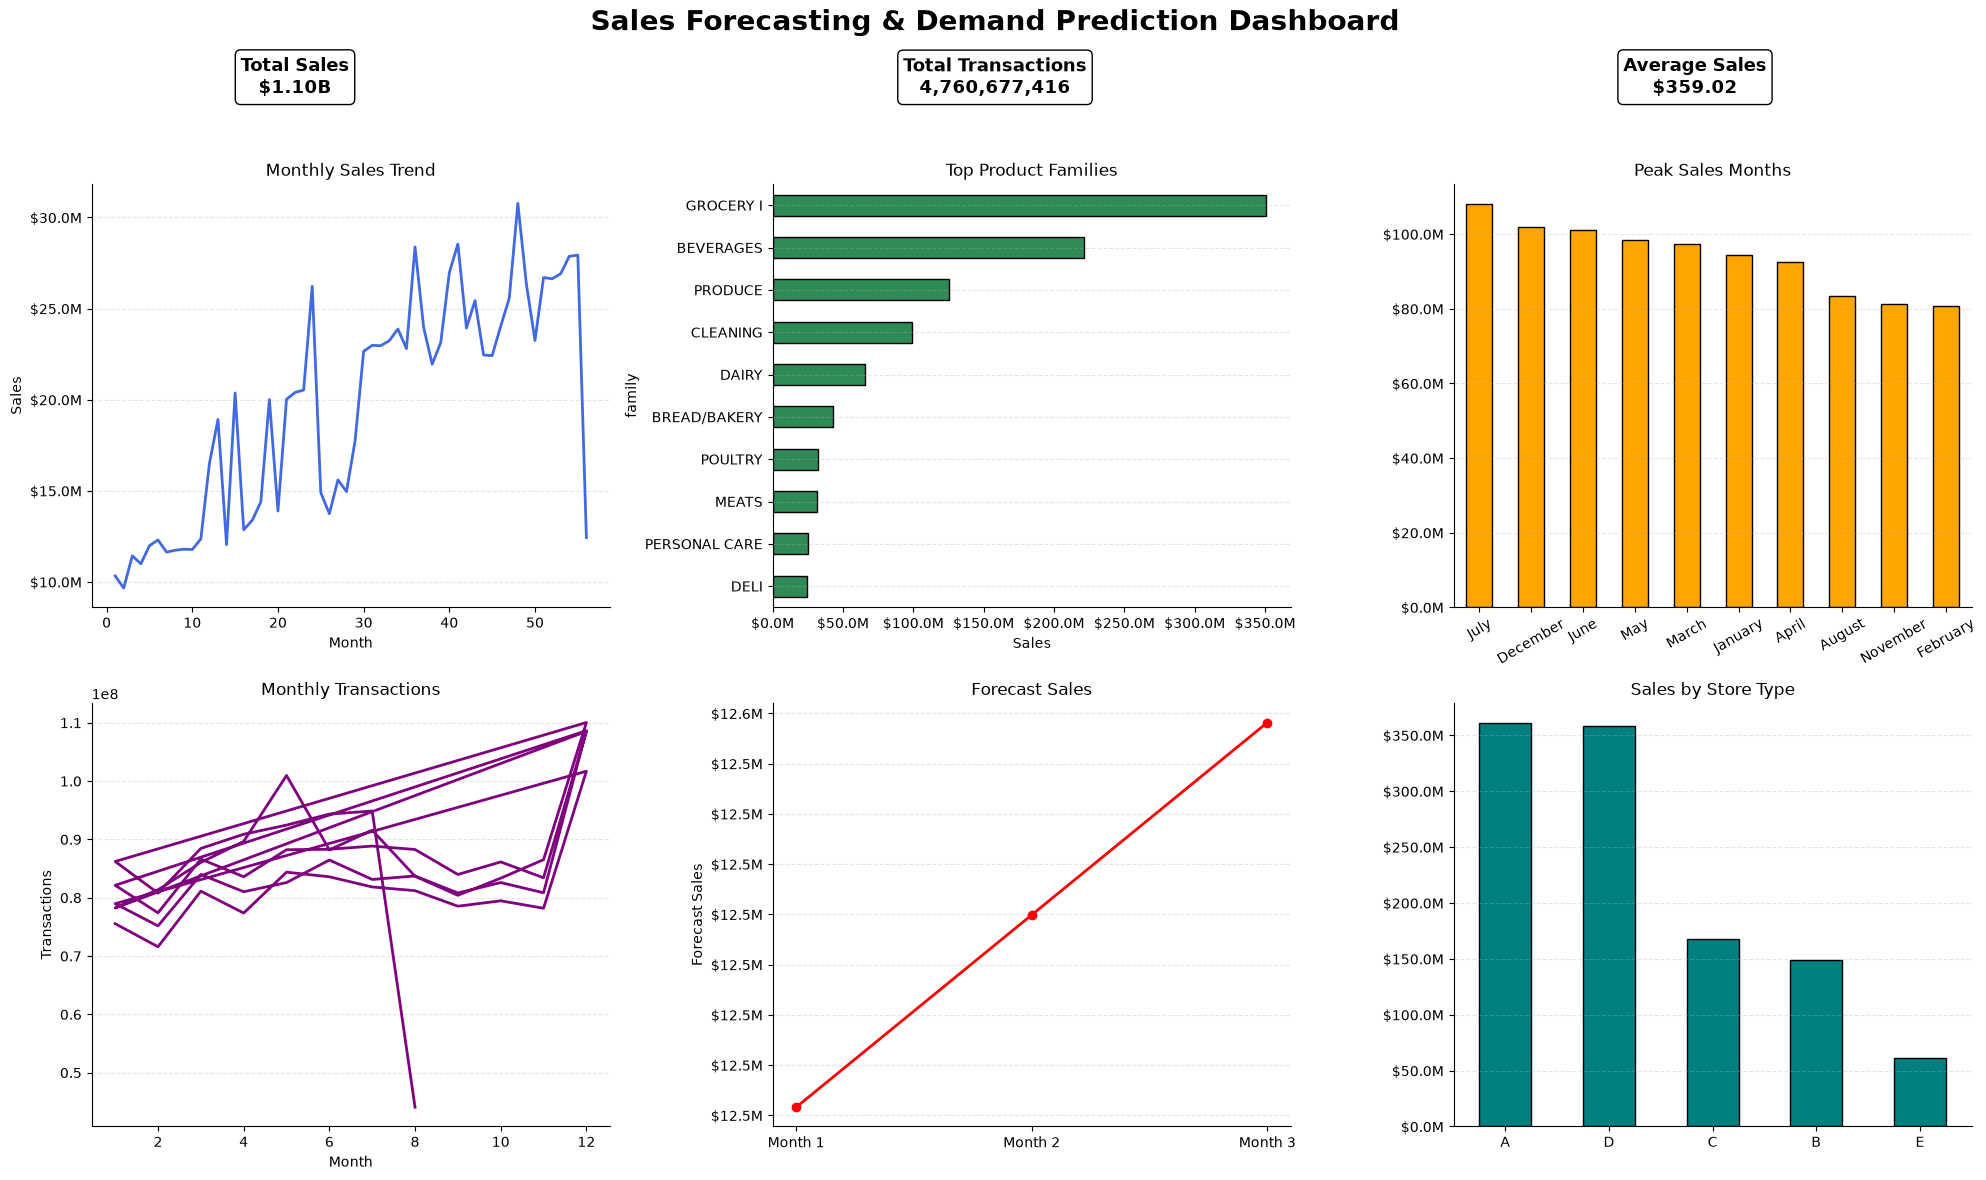

In [106]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(2, 3, figsize = (20, 12))

# Set dashboard background
dashboard_figure.patch.set_facecolor('white')

# Dashboard title
dashboard_figure.suptitle(
    'Sales Forecasting & Demand Prediction Dashboard',
    fontsize = 20,
    fontweight = 'bold')

# KPI Cards
dashboard_figure.text(
    0.15,
    0.91,
    f'Total Sales\n${total_sales / 1e9:.2f}B',
    fontsize = 13,
    fontweight = 'bold',
    ha = 'center',
    bbox = dict(
        facecolor = 'white',
        edgecolor = 'black',
        boxstyle = 'round'))

dashboard_figure.text(
    0.50,
    0.91,
    f'Total Transactions\n{total_transactions:,.0f}',
    fontsize = 13,
    fontweight = 'bold',
    ha = 'center',
    bbox = dict(
        facecolor = 'white',
        edgecolor = 'black',
        boxstyle = 'round'))

dashboard_figure.text(
    0.85,
    0.91,
    f'Average Sales\n${average_sales:.2f}',
    fontsize = 13,
    fontweight = 'bold',
    ha = 'center',
    bbox = dict(
        facecolor = 'white',
        edgecolor = 'black',
        boxstyle = 'round'))

# Format values
billions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x / 1e9:.1f}B')

millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x / 1e6:.1f}M')

# Chart 1 : Monthly Sales Trend
dashboard_axes[0, 0].plot(
    forecast_data['Period'],
    forecast_data['sales'],
    color = 'royalblue',
    linewidth = 2)

dashboard_axes[0, 0].set_title('Monthly Sales Trend')
dashboard_axes[0, 0].set_xlabel('Month')
dashboard_axes[0, 0].set_ylabel('Sales')
dashboard_axes[0, 0].yaxis.set_major_formatter(millions_formatter)

# Chart 2 : Sales by Product Family
top_products.head(10).sort_values().plot(
    kind = 'barh',
    ax = dashboard_axes[0, 1],
    color = 'seagreen',
    edgecolor = 'black')

dashboard_axes[0, 1].set_title('Top Product Families')
dashboard_axes[0, 1].set_xlabel('Sales')
dashboard_axes[0, 1].xaxis.set_major_formatter(millions_formatter)

# Chart 3 : Peak Sales Months

# Convert Series to DataFrame if needed
if isinstance(monthly_sales, pd.Series):

    peak_sales = (
        monthly_sales
        .sort_values(ascending=False)
        .head(10))

    peak_sales.plot(
        kind='bar',
        ax=dashboard_axes[0, 2],
        color='orange',
        edgecolor='black')

else:

    (
        monthly_sales
        .sort_values(by='sales', ascending=False)
        .head(10)
        .plot(
            kind='bar',
            x='Month_Name',
            y='sales',
            ax=dashboard_axes[0, 2],
            color='orange',
            edgecolor='black'))

dashboard_axes[0, 2].set_title('Peak Sales Months')
dashboard_axes[0, 2].set_xlabel('')
dashboard_axes[0, 2].tick_params(axis='x', rotation=30)
dashboard_axes[0, 2].yaxis.set_major_formatter(millions_formatter)

# Chart 4 : Transactions Trend
dashboard_axes[1, 0].plot(
    monthly_transactions['Month'],
    monthly_transactions['transactions'],
    color = 'purple',
    linewidth = 2)

dashboard_axes[1, 0].set_title('Monthly Transactions')
dashboard_axes[1, 0].set_xlabel('Month')
dashboard_axes[1, 0].set_ylabel('Transactions')

# Chart 5 : Forecast Sales
dashboard_axes[1, 1].plot(
    forecast_result['Forecast_Month'],
    forecast_result['Forecast_Sales'],
    marker = 'o',
    linewidth = 2,
    color = 'red')

dashboard_axes[1, 1].set_title('Forecast Sales')
dashboard_axes[1, 1].set_xlabel('')
dashboard_axes[1, 1].set_ylabel('Forecast Sales')
dashboard_axes[1, 1].yaxis.set_major_formatter(millions_formatter)

# Chart 6 : Sales by Store Type
store_type_sales.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 2],
    color = 'teal',
    edgecolor = 'black')

dashboard_axes[1, 2].set_title('Sales by Store Type')
dashboard_axes[1, 2].set_xlabel('')
dashboard_axes[1, 2].tick_params(axis = 'x', rotation = 0)
dashboard_axes[1, 2].yaxis.set_major_formatter(millions_formatter)

# Improve readability
for row in dashboard_axes:

    for chart in row:

        chart.grid(
            axis = 'y',
            linestyle = '--',
            alpha = 0.3
        )

        chart.spines['top'].set_visible(False)

        chart.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.90])

# Save dashboard
plt.savefig(
    '4_Final_Project_Dashboard.png',
    dpi = 300,
    bbox_inches = 'tight')

# Display dashboard
plt.show()

#### Information

> Dataset: Store Sales Forecasting & Demand Prediction

> Source Files:
> - train.csv
> - stores.csv
> - transactions.csv
> - holidays_events.csv

> Final Dataset: Merged Sales Dataset

> Rows: 3,054,348

> Columns: 25

> Added Features:
> - Year
> - Month
> - Month_Name
> - Week
> - Day
> - Day_Name
> - Quarter
> - Weekend
> - Holiday_Flag

> Data Cleaning:
> - Duplicate records were removed.
> - Missing values were handled.
> - Date columns were formatted.
> - Datasets were merged successfully.

#### Data Insights

> Total Sales reached approximately **$1.10 Billion**.

> Total Transactions exceeded **4.76 Billion**.

> The dataset contains **54 stores**, **33 product families**, **22 cities**, and **16 states**.

> Grocery I generated the highest sales, contributing nearly **32%** of total revenue.

> Store 44 recorded the highest sales among all stores.

> Quito generated the highest sales among all cities.

> July was the highest sales month, while Quarter 2 recorded the highest overall sales.

#### Business Insights

> Grocery I is the main revenue driver and should remain a business priority.

> Sales increase during specific months, showing clear seasonal demand patterns.

> Quito and the top-performing stores contribute a significant share of total sales.

> Promotions support sales growth for high-demand product families.

> Customer demand remains strong in stores with consistently high transaction volumes.

#### Risks

> Heavy dependence on Grocery I for overall sales.

> Low-performing stores may reduce overall business growth.

> Seasonal demand fluctuations can affect inventory planning.

> Incorrect demand forecasting may lead to stock shortages or excess inventory.

#### Opportunities

> Increase inventory for high-demand product families.

> Improve performance of low-selling stores.

> Plan promotions before peak sales seasons.

> Use historical sales trends to improve demand forecasting.

#### Recommendations

> Increase inventory for Grocery I and other high-selling product families.

> Maintain sufficient stock before peak sales months.

> Focus marketing efforts on high-performing cities and stores.

> Improve inventory planning using monthly sales trends.

> Continuously monitor customer demand and transaction patterns.

#### Expected Business Impact

> Better inventory planning.

> Higher sales revenue.

> Reduced stock shortages.

> Improved demand forecasting.

> Better store performance.

#### Future Prediction

> Based on historical sales trends, demand is expected to remain strong for high-selling product families. Seasonal demand patterns are likely to continue, making demand forecasting and inventory planning important for future business growth.